# New Simulation (Not diving by N)

In [13]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from qutip import *
import numpy as np
from scipy.special import jn_zeros

def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N/2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 /(N-1) * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx


def run_dynamics_lmg(args):
    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    
    H0, H1, H2, H_int, Sx_full, Sz_full, Sx = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)
    H_td = [H0 + H2 + H_int, [H1,h_t]]
    en, sts = Sx.eigenstates() 
    rho = sts[0]
    psi_ph = basis(n_ph,0)
    rho0 = tensor(rho, psi_ph)
    results = mesolve(H_td, rho0, tlist, [], [], args = args, options=args['opts'])
    psi_ts = results.states

    E0 = np.array(expect(H0, psi_ts))
    E1 = np.array(expect(H1, psi_ts))
    drive_vals = args['h0'] + args['h'] * np.cos(args['omega'] * tlist)
    energies_spin = (E0 + drive_vals * E1)/N
    H_spin = np.sqrt(np.mean(energies_spin**2) - np.mean(energies_spin)**2)

    E2 = np.array(expect(H2, psi_ts))
    energies_ph = E2
    H_ph = np.sqrt(np.mean(energies_ph**2) - np.mean(energies_ph)**2)

    avg_ph_energy = np.mean(energies_ph)

    return H_spin, H_ph, avg_ph_energy

Running g = 0


100%|██████████| 8/8 [00:00<00:00, 5976.92it/s]


Running g = 0.01


100%|██████████| 8/8 [00:00<00:00, 11765.23it/s]


Running g = 0.05


100%|██████████| 8/8 [00:00<00:00, 17763.07it/s]


Running g = 0.1


100%|██████████| 8/8 [00:00<00:00, 14296.73it/s]


Running g = 0.2


100%|██████████| 8/8 [00:00<00:00, 15797.76it/s]


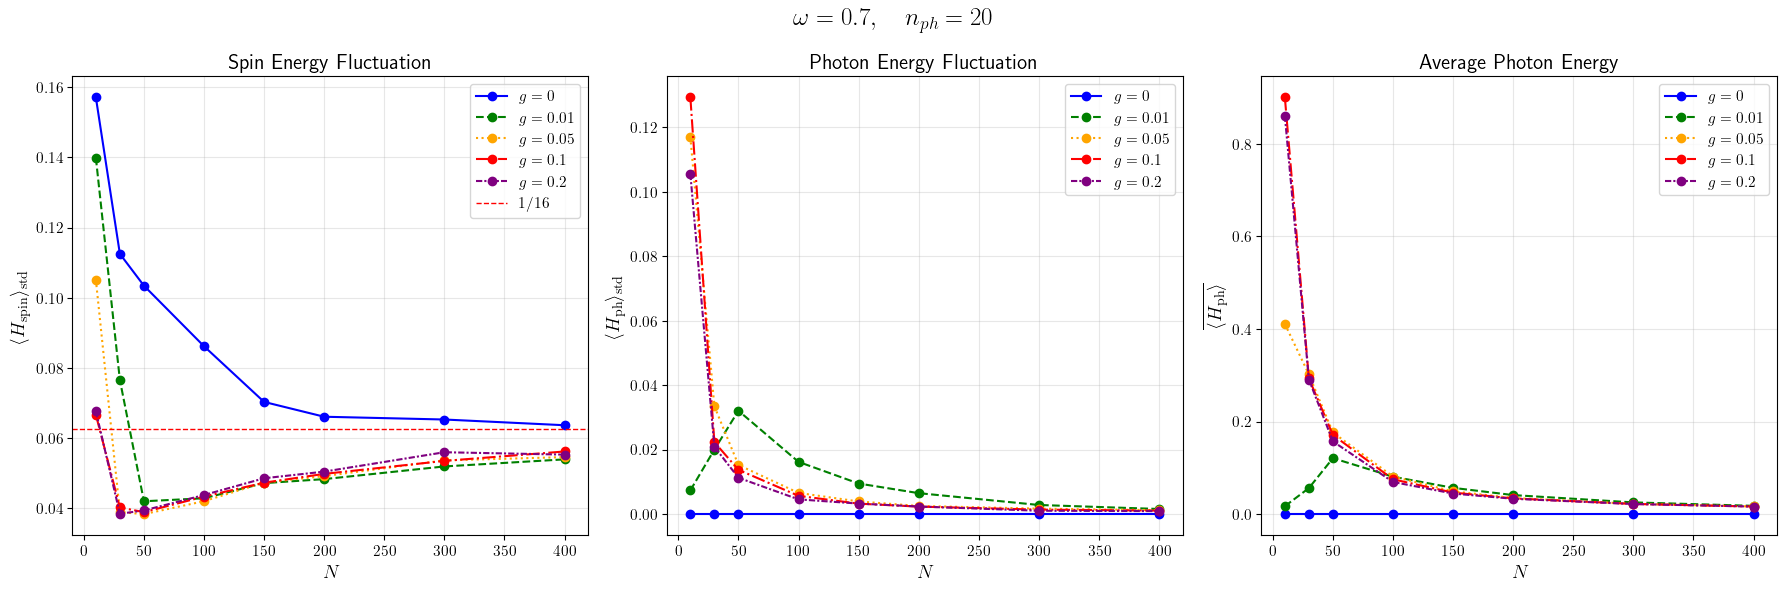

In [14]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm
import numpy as np

plt.rcParams.update({"figure.figsize": (12,6), "font.size": 11, "text.usetex": True})

omega = 0.7
hbar = 1.0
h0 = 0
n_ph = 20
omega0 = 1.0
Jvalue = 1.0

gvals = [0, 0.01, 0.05, 0.1, 0.2]
#gvals = [0.01, 0.2]
Nvals = [10, 30, 50, 100, 150, 200, 300, 400]
#Nvals = [4, 6, 8]
opts = Options(nsteps=int(1e6), atol=1e-10, rtol=1e-8)

T = 2*np.pi/omega
tlist = np.linspace(0, 200*T, 1000)
h = jn_zeros(0,5)[1] * omega / 4.0

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=False)

titles = [r'Spin Energy Fluctuation', r'Photon Energy Fluctuation', r'Average Photon Energy']
ylabels = [r'$\langle H_{\rm spin}\rangle_{\rm std}$', r'$\langle H_{\rm ph}\rangle_{\rm std}$', r'$\overline{\langle H_{\rm ph}\rangle}$']
colors = ['blue', 'green', 'orange', 'red', 'purple']
styles = ['-', '--', ':', '-.', (0, (3,1,1,1))]

with Pool(processes=6) as p:

    for g, c, s in zip(gvals, colors, styles):

        print(f'Running g = {g}')

        args_list = [{'tlist': tlist, 'N': N, 'n_ph': n_ph, 'g': g, 'hbar': hbar, 'omega0': omega0, 'Jvalue': Jvalue, 'h0': h0, 'h': h, 'omega': omega, 'opts': opts} 
            for N in Nvals]

        results = np.array(p.map(run_dynamics_lmg, tqdm(args_list)))

        H_spin = results[:,0]
        H_ph = results[:,1]
        avg_ph = results[:,2]

        observables = [H_spin, H_ph, avg_ph]

        np.savez(f'data/New_H_std_avg_ph_nph_{n_ph}_g_{g}.npz', Nvals=Nvals, H_spin=H_spin, H_ph=H_ph, avg_ph=avg_ph)
        
        for ax, obs in zip(axes, observables):

            ax.plot(Nvals, obs, marker='o', color=c, linestyle=s, linewidth=1.5, label=rf'$g={g}$')

axes[0].axhline(1/16, color='red', linestyle='--', linewidth=1, label=r'$1/16$')

for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set_xlabel(r'$N$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(rf'$\omega={omega},\quad n_{{ph}}={n_ph}$', fontsize=18)
plt.tight_layout()
plt.savefig(f'plots/New_H_std_avg_ph_nph_{n_ph}_omega_{omega}.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from qutip import *
import numpy as np
from scipy.special import jn_zeros

def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N/2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 /(N-1) * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx


def run_dynamics_lmg(args):
    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    
    H0, H1, H2, H_int, Sx_full, Sz_full, Sx = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)
    H_td = [H0 + H2 + H_int, [H1,h_t]]
    en, sts = Sx.eigenstates() 
    rho = sts[0]
    psi_ph = basis(n_ph,0)
    rho0 = tensor(rho, psi_ph)
    results = mesolve(H_td, rho0, tlist, [], [], args = args, options=args['opts'])
    psi_ts = results.states

    E0 = np.array(expect(H0, psi_ts))
    E1 = np.array(expect(H1, psi_ts))
    drive_vals = args['h0'] + args['h'] * np.cos(args['omega'] * tlist)
    energies_spin = (E0 + drive_vals * E1)/N
    H_spin = np.sqrt(np.mean(energies_spin**2) - np.mean(energies_spin)**2)

    E2 = np.array(expect(H2, psi_ts))
    energies_ph = E2
    H_ph = np.sqrt(np.mean(energies_ph**2) - np.mean(energies_ph)**2)

    avg_ph_energy = np.mean(energies_ph)

    return H_spin, H_ph, avg_ph_energy

Running g = 1


100%|██████████| 8/8 [00:00<00:00, 4968.08it/s]


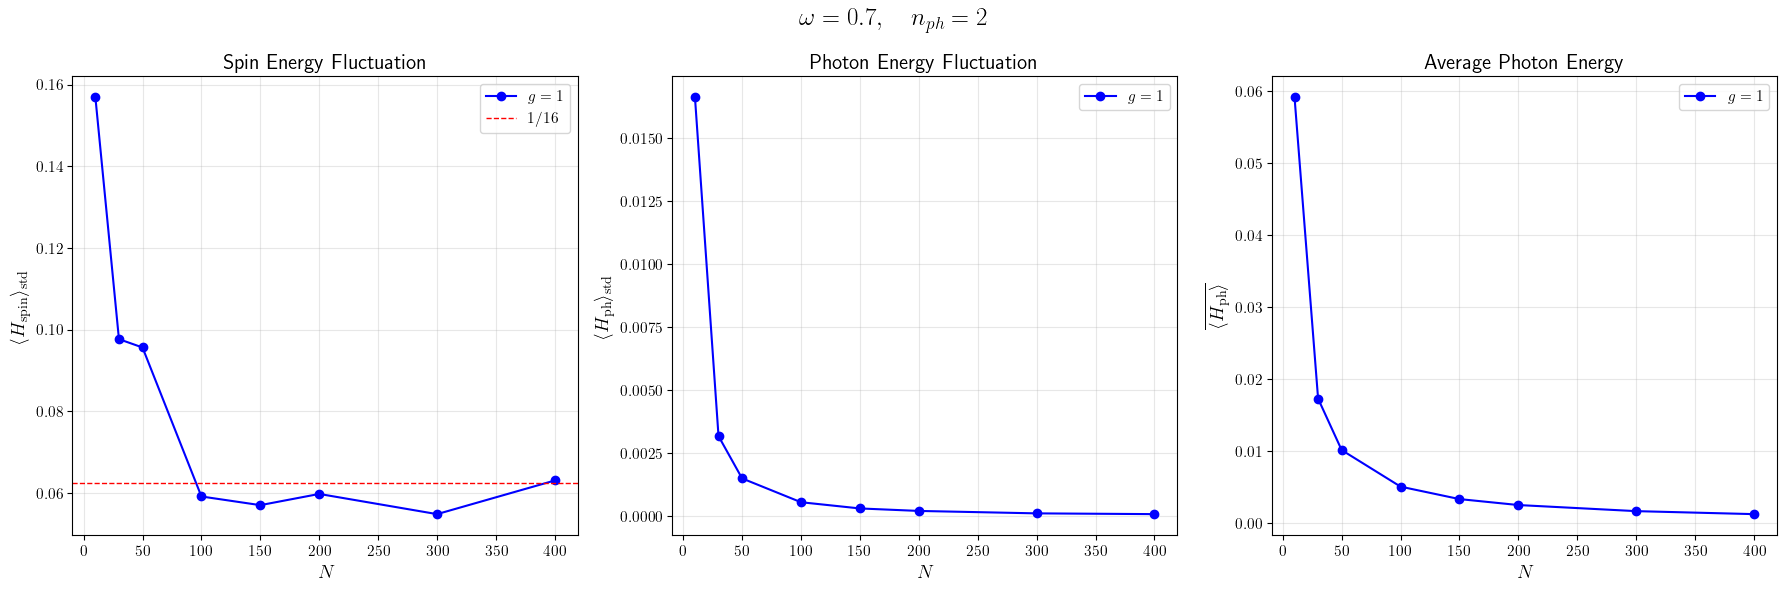

In [4]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm
import numpy as np

plt.rcParams.update({"figure.figsize": (12,6), "font.size": 11, "text.usetex": True})

omega = 0.7
hbar = 1.0
h0 = 0
n_ph = 2
omega0 = 1.0
Jvalue = 1.0

#gvals = [0, 0.01, 0.05, 0.1, 0.2]
gvals = [1]
Nvals = [10, 30, 50, 100, 150, 200, 300, 400]
#Nvals = [4, 6, 8]
opts = Options(nsteps=int(1e6), atol=1e-10, rtol=1e-8)

T = 2*np.pi/omega
tlist = np.linspace(0, 200*T, 1000)
h = jn_zeros(0,5)[1] * omega / 4.0

fig, axes = plt.subplots(1, 3, figsize=(18,6), sharey=False)

titles = [r'Spin Energy Fluctuation', r'Photon Energy Fluctuation', r'Average Photon Energy']
ylabels = [r'$\langle H_{\rm spin}\rangle_{\rm std}$', r'$\langle H_{\rm ph}\rangle_{\rm std}$', r'$\overline{\langle H_{\rm ph}\rangle}$']
colors = ['blue', 'green', 'orange', 'red', 'purple']
styles = ['-', '--', ':', '-.', (0, (3,1,1,1))]

with Pool(processes=8) as p:

    for g, c, s in zip(gvals, colors, styles):

        print(f'Running g = {g}')

        args_list = [{'tlist': tlist, 'N': N, 'n_ph': n_ph, 'g': g, 'hbar': hbar, 'omega0': omega0, 'Jvalue': Jvalue, 'h0': h0, 'h': h, 'omega': omega, 'opts': opts} 
            for N in Nvals]

        results = np.array(p.map(run_dynamics_lmg, tqdm(args_list)))

        H_spin = results[:,0]
        H_ph = results[:,1]
        avg_ph = results[:,2]

        observables = [H_spin, H_ph, avg_ph]

        np.savez(f'data/New(1)_H_std_avgph_nph_{n_ph}_g_{g}.npz', Nvals=Nvals, H_spin=H_spin, H_ph=H_ph, avg_ph=avg_ph)
        
        for ax, obs in zip(axes, observables):

            ax.plot(Nvals, obs, marker='o', color=c, linestyle=s, linewidth=1.5, label=rf'$g={g}$')

axes[0].axhline(1/16, color='red', linestyle='--', linewidth=1, label=r'$1/16$')

for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set_xlabel(r'$N$', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(rf'$\omega={omega},\quad n_{{ph}}={n_ph}$', fontsize=18)
plt.tight_layout()
plt.savefig(f'plots/New(1)_H_std_avgph_nph_{n_ph}_omega_{omega}.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from qutip import *
import numpy as np
from scipy.special import jn_zeros

def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N/2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)
    n_photon = adag_full * a_full

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 /(N-1) * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx, n_photon


def run_dynamics_lmg(args):
    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx, n_photon = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)
    H_td = [H0 + H2 + H_int, [H1,h_t]]
    en, sts = Sx.eigenstates() 
    rho = sts[0]
    psi_ph = basis(n_ph,0)
    rho0 = tensor(rho, psi_ph)
    results = mesolve(H_td, rho0, tlist, [], [n_photon], args = args, options=args['opts'])
    op_n_photon = results.expect[0]

    return op_n_photon

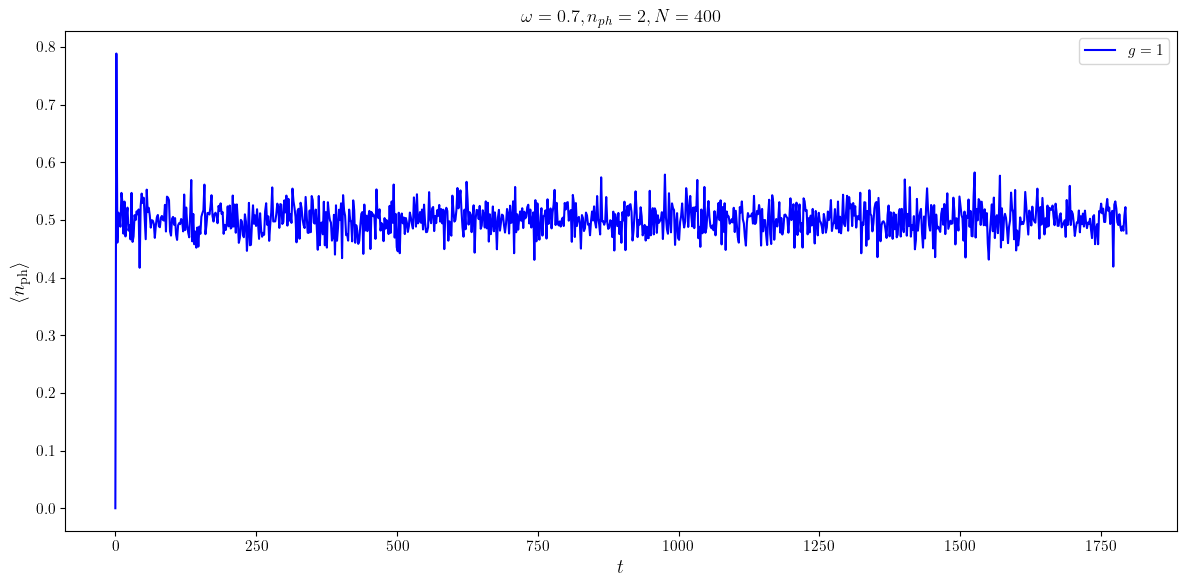

In [7]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

plt.rcParams.update({"figure.figsize": (12,6), "font.size": 11, "text.usetex": True})
# parameters
N = 400
omega = 0.7
hbar = 1.0
h0 = 0
n_ph = 2
omega0 = 1.0
Jvalue = 1.0

gvals = [1]
#Nvals = [10, 30, 50, 100, 150, 200, 300, 400]
#Nvals = [4, 5, 6]
opts = Options(nsteps =1e6, atol=1e-10, rtol=1e-8)

T = 2 * np.pi/omega
tlist = np.linspace(0,200*T, 1000)
h = jn_zeros(0,5)[1]* omega / 4.0

colors = ['blue', 'green']
styles = ['-', '--']
for g, c, s in zip(gvals, colors, styles):
    
    args_list = {'tlist': tlist, 'N': N, 'n_ph': n_ph, 'g': g, 'hbar': hbar, 'omega0': omega0, 'Jvalue': Jvalue, 'h0': h0, 'h': h, 'omega': omega, 'opts': opts}            
    op_n_photon = run_dynamics_lmg(args_list)    
    np.savez(f'New_Average_photon_number_N_{N}_n_ph_{n_ph}_g_{g}.npz', op_n_photon=op_n_photon, tlist=tlist)
    plt.plot(tlist, op_n_photon, label=rf'$g={g}$', color=c, linestyle=s)

plt.xlabel(r'$t$', fontsize=14)
plt.ylabel(r'$\langle n_{\mathrm{ph}}\rangle$', fontsize=14)
plt.title(rf'$\omega={omega}, n_{{ph}}={n_ph}, N={N}$')
plt.tight_layout()
plt.legend()
plt.savefig(f'plots/New_Average_photon_number_n_ph_{n_ph}_N_{N}_omega_{omega}_g_{g}.png', dpi=300, bbox_inches='tight')
plt.show()

In [8]:
import numpy as np

# -------------------------------------------------
# load saved data
# -------------------------------------------------

data_01 = np.load('New_Average_photon_number_N_400_n_ph_2_g_1.npz')

#data_02 = np.load('New_Average_photon_number_N_400_n_ph_2_g_0.2.npz')

# -------------------------------------------------
# extract signals
# -------------------------------------------------

n_01 = data_01['op_n_photon']

#n_02 = data_02['op_n_photon']

# -------------------------------------------------
# remove transient
# -------------------------------------------------

steady_01 = n_01[-500:]

#steady_02 = n_02[-500:]

# -------------------------------------------------
# temporal standard deviation
# -------------------------------------------------

std_01 = np.std(steady_01)

#std_02 = np.std(steady_02)

# -------------------------------------------------
# print results
# -------------------------------------------------

print(f'g = 1  --> temporal fluctuation = {std_01}')

#print(f'g = 0.2   --> temporal fluctuation = {std_02}')

g = 1  --> temporal fluctuation = 0.025163044490427857


In [4]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

from qutip import *
import numpy as np
from scipy.special import jn_zeros

def h_t(t, args):
    h = args['h']
    h0 = args['h0']
    w = args['omega']
    return h0 + h * np.cos(w * t)

def h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue):

    S = N/2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # cavity
    a = destroy(n_ph)
    adag = a.dag()
    I_ph = qeye(n_ph)

    # -------- tensor lift --------
    Sx_full = tensor(Sx, I_ph)
    Sz_full = tensor(Sz, I_ph)
    Sz2_full = tensor(Sz2, I_ph)

    a_full = tensor(I_spin, a)
    adag_full = tensor(I_spin, adag)
    n_photon = adag_full * a_full

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -2/(N-1) * Sz2_full

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx_full

    # cavity energy
    H2 = hbar * omega0 /(N-1) * (adag_full * a_full)

    # light-matter coupling
    H_int = (2 * g / np.sqrt(N)) * (a_full + adag_full) * Sx_full

    return H0, H1, H2, H_int, Sx_full, Sz_full, Sx, n_photon


def run_dynamics_lmg(args):
    tlist = args['tlist']
    N = args['N']
    n_ph = args['n_ph']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, H2, H_int, Sx_full, Sz_full, Sx, n_photon = h0_ham_lmg(N, n_ph, g, hbar, omega0, Jvalue)
    H_td = [H0 + H2 + H_int, [H1,h_t]]
    en, sts = Sx.eigenstates() 
    rho = sts[0]
    psi_ph = basis(n_ph,0)
    rho0 = tensor(rho, psi_ph)
    results = mesolve(H_td, rho0, tlist, [], [n_photon], args = args, options=args['opts'])
    op_n_photon = results.expect[0]

    return op_n_photon

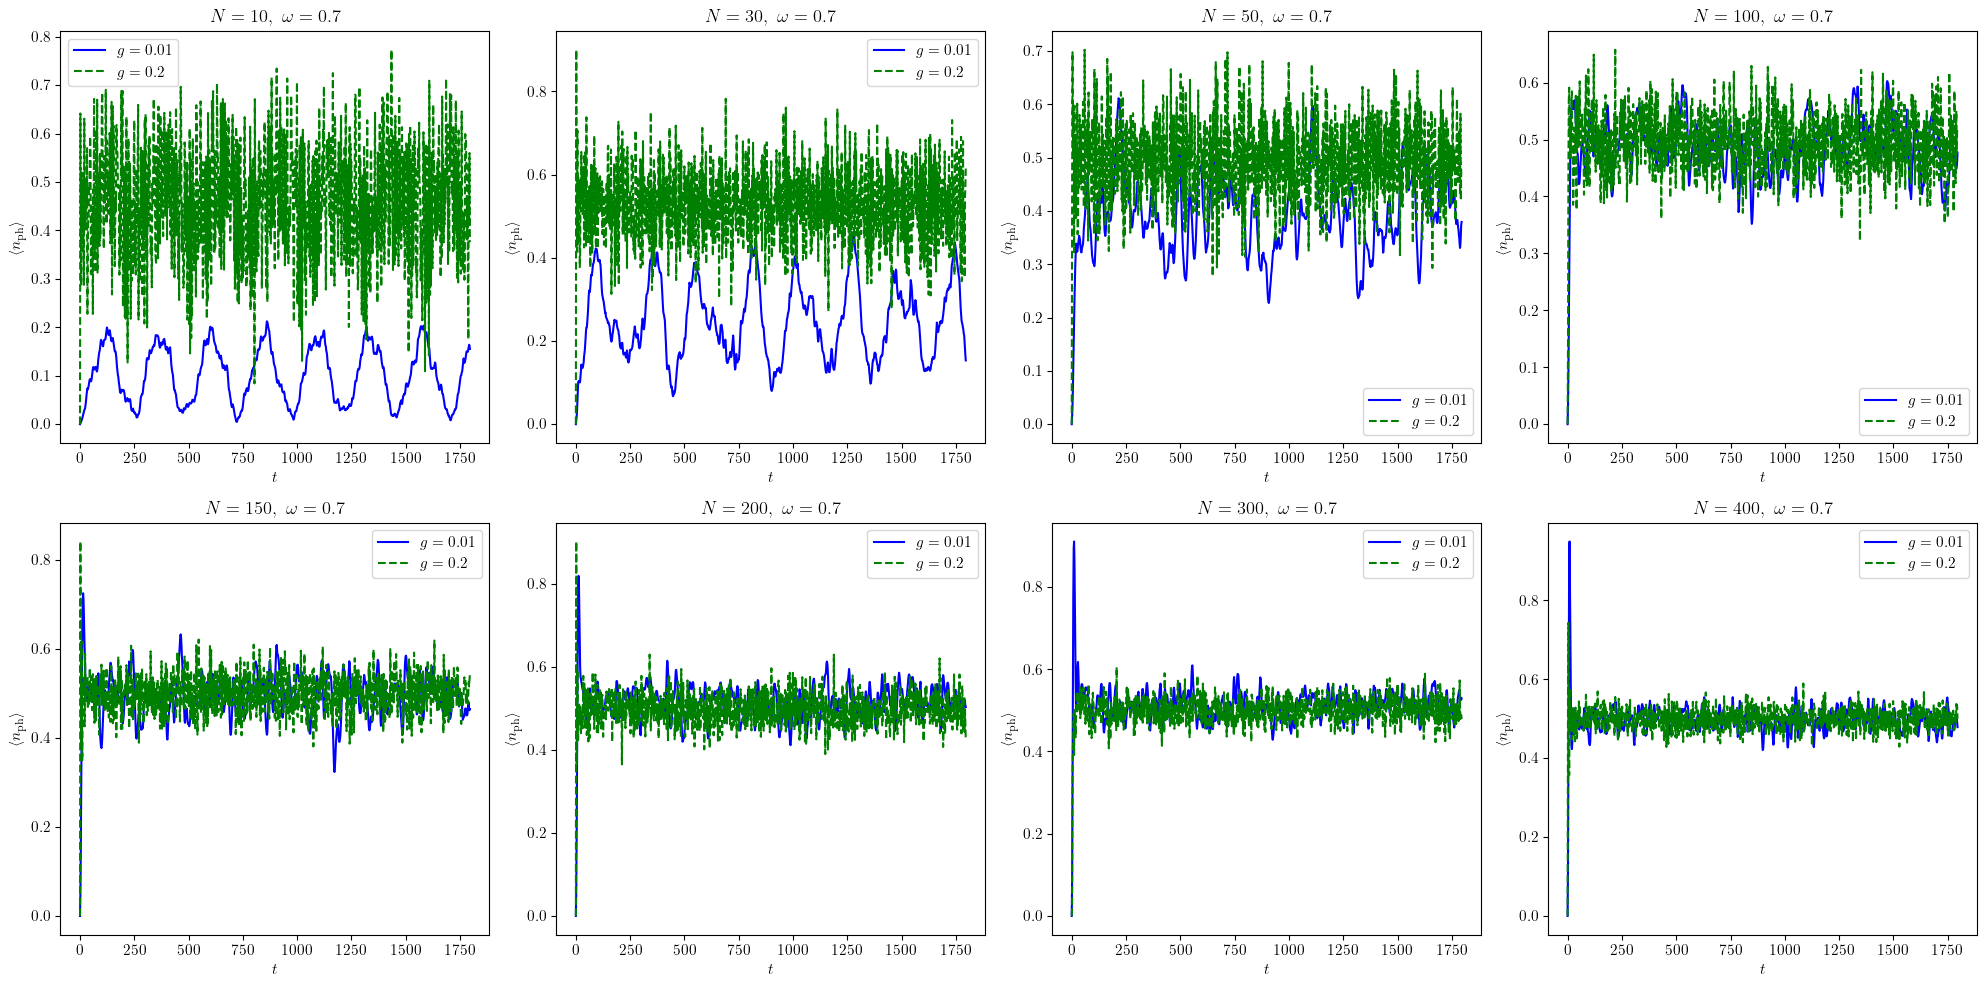

In [5]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

plt.rcParams.update({"figure.figsize": (12,6), "font.size": 11, "text.usetex": True})
# parameters
omega = 0.7
hbar = 1.0
h0 = 0
n_ph = 2
omega0 = 1.0
Jvalue = 1.0

gvals = [0.01, 0.2]
Nvals = [10, 30, 50, 100, 150, 200, 300, 400]
#Nvals = [4, 5, 6]
opts = Options(nsteps =1e6, atol=1e-10, rtol=1e-8)

T = 2 * np.pi/omega
tlist = np.linspace(0,200*T, 1000)
h = jn_zeros(0,5)[1]* omega / 4.0

fig, axes = plt.subplots(2, 4, figsize=(20,10), sharey=False)
axes = axes.flatten()

colors = ['blue', 'green']
styles = ['-', '--']
for N, ax in zip(Nvals, axes):
    for g, c, s in zip(gvals, colors, styles):
        
        args_list = {'tlist': tlist, 'N': N, 'n_ph': n_ph, 'g': g, 'hbar': hbar, 'omega0': omega0, 'Jvalue': Jvalue, 'h0': h0, 'h': h, 'omega': omega, 'opts': opts}                
        op_n_photon = run_dynamics_lmg(args_list)        
        np.savez(f'New_Average_photon_numbers_N_{N}_n_ph_{n_ph}_g_{g}.npz', op_n_photon=op_n_photon, tlist=tlist)
        ax.plot(tlist, op_n_photon, label=rf'$g={g}$', color=c, linestyle=s)

    ax.set_title(rf'$N={N},\ \omega={omega}$')
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$\langle n_{{\mathrm{{ph}}}}\rangle$')
    ax.legend()

plt.tight_layout()
plt.savefig(f'plots/New_Average_photon_numbers_n_ph_{n_ph}_omega_{omega}.png', dpi=300, bbox_inches='tight')
plt.show()